<a href="https://colab.research.google.com/github/snig0708/energy-consumption-forecasting/blob/main/energy_consumption_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device}" " is available.")

cuda is available.


In [ ]:


from google.colab import files
data_to_load = files.upload()

Saving PJME_hourly.csv to PJME_hourly.csv


In [ ]:

import io
df = pd.read_csv(io.BytesIO(data_to_load['PJME_hourly.csv']))

In [ ]:
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [ ]:
df.tail()

,Datetime,PJME_MW
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0
145365,2018-01-02 00:00:00,38608.0


In [ ]:
df.shape

(145366, 2)

In [ ]:
df = df.rename(columns={
    "Datetime": "datetime",
    "PJME_MW": "value"
})

In [ ]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   datetime  145366 non-null  datetime64[ns]
 1   value     145366 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 MB


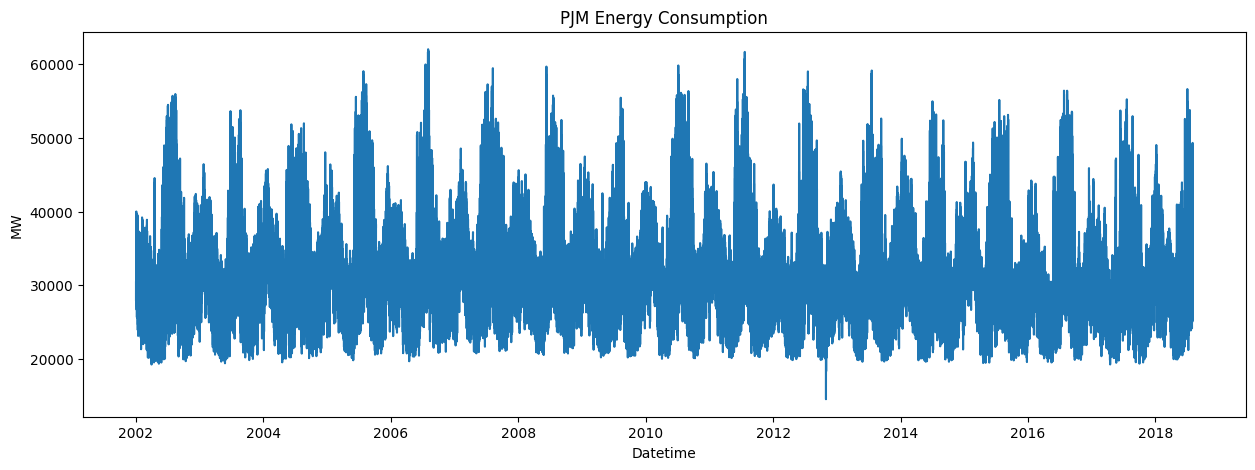

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df["datetime"], df["value"])
plt.title("PJM Energy Consumption")
plt.xlabel("Datetime")
plt.ylabel("MW")
plt.show()

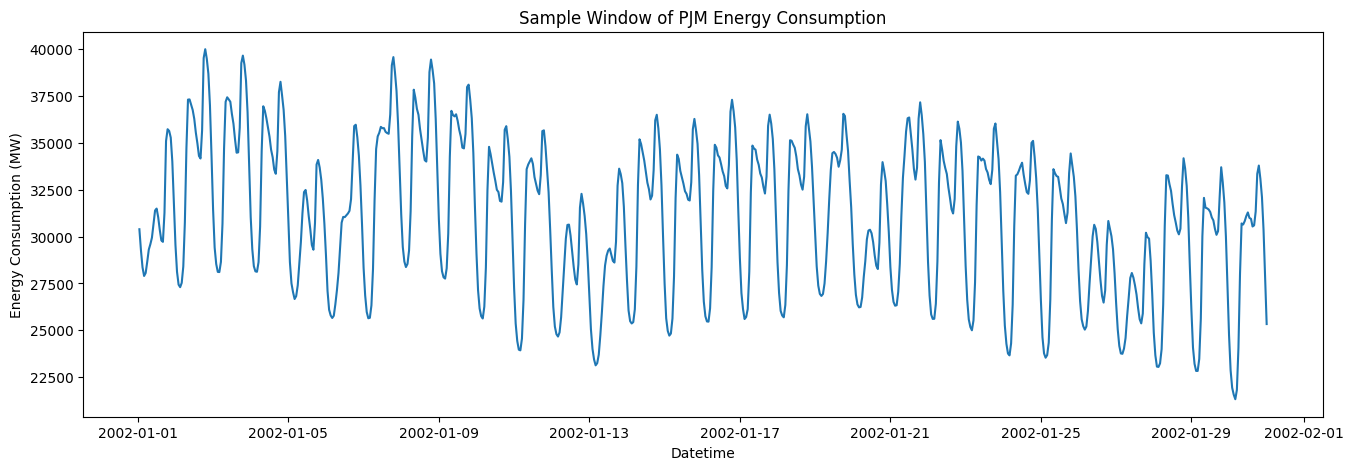

In [ ]:
plt.figure(figsize=(16, 5))
sample_df = df.iloc[:24*30]  # first 30 days
plt.plot(sample_df["datetime"], sample_df["value"])
plt.title("Sample Window of PJM Energy Consumption")
plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")
plt.show()

In [ ]:
train_size = int(len(df) * 0.8)

train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 116292
Test size: 29074


In [ ]:
scaler = MinMaxScaler()

train_values = scaler.fit_transform(train_df[["value"]])
test_values = scaler.transform(test_df[["value"]])

In [ ]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 24

X_train, y_train = create_sequences(train_values, SEQ_LENGTH)
X_test, y_test = create_sequences(test_values, SEQ_LENGTH)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (116268, 24, 1)
y_train shape: (116268, 1)
X_test shape: (29050, 24, 1)
y_test shape: (29050, 1)


In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# Define the models

class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
# Training the models

def train_model(model, train_loader, test_loader, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        running_test_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                running_test_loss += loss.item()

        avg_test_loss = running_test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")

    return model, train_losses, test_losses

In [ ]:
# Get preds

def get_predictions(model, data_loader):
    model.eval()
    preds = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)

            preds.extend(outputs.cpu().numpy())
            actuals.extend(y_batch.numpy())

    preds = np.array(preds)
    actuals = np.array(actuals)

    return preds, actuals

In [ ]:
# Evaluation
def evaluate_model(model, data_loader, scaler, model_name="Model"):
    preds, actuals = get_predictions(model, data_loader)

    preds_inv = scaler.inverse_transform(preds.reshape(-1, 1))
    actuals_inv = scaler.inverse_transform(actuals.reshape(-1, 1))

    mae = mean_absolute_error(actuals_inv, preds_inv)
    rmse = np.sqrt(mean_squared_error(actuals_inv, preds_inv))

    print(f"{model_name} MAE: {mae:.4f}")
    print(f"{model_name} RMSE: {rmse:.4f}")

    return preds_inv, actuals_inv, mae, rmse

In [ ]:
rnn_model = RNNModel()
rnn_model, rnn_train_losses, rnn_test_losses = train_model(
    rnn_model, train_loader, test_loader, epochs=10, lr=0.001
)

Epoch [1/10] | Train Loss: 0.001314 | Test Loss: 0.000486
Epoch [2/10] | Train Loss: 0.000221 | Test Loss: 0.000225
Epoch [3/10] | Train Loss: 0.000224 | Test Loss: 0.000464
Epoch [4/10] | Train Loss: 0.000203 | Test Loss: 0.000182
Epoch [5/10] | Train Loss: 0.000199 | Test Loss: 0.000219
Epoch [6/10] | Train Loss: 0.000192 | Test Loss: 0.000291
Epoch [7/10] | Train Loss: 0.000195 | Test Loss: 0.000245
Epoch [8/10] | Train Loss: 0.000191 | Test Loss: 0.000281
Epoch [9/10] | Train Loss: 0.000184 | Test Loss: 0.000263
Epoch [10/10] | Train Loss: 0.000182 | Test Loss: 0.000230


In [ ]:
lstm_model = LSTMModel()
lstm_model, lstm_train_losses, lstm_test_losses = train_model(
    lstm_model, train_loader, test_loader, epochs=10, lr=0.001
)

Epoch [1/10] | Train Loss: 0.003596 | Test Loss: 0.000354
Epoch [2/10] | Train Loss: 0.000200 | Test Loss: 0.000133
Epoch [3/10] | Train Loss: 0.000125 | Test Loss: 0.000150
Epoch [4/10] | Train Loss: 0.000118 | Test Loss: 0.000144
Epoch [5/10] | Train Loss: 0.000099 | Test Loss: 0.000159
Epoch [6/10] | Train Loss: 0.000089 | Test Loss: 0.000104
Epoch [7/10] | Train Loss: 0.000082 | Test Loss: 0.000100
Epoch [8/10] | Train Loss: 0.000077 | Test Loss: 0.000112
Epoch [9/10] | Train Loss: 0.000073 | Test Loss: 0.000129
Epoch [10/10] | Train Loss: 0.000071 | Test Loss: 0.000138


In [ ]:
gru_model = GRUModel()
gru_model, gru_train_losses, gru_test_losses = train_model(
    gru_model, train_loader, test_loader, epochs=10, lr=0.001
)


Epoch [1/10] | Train Loss: 0.001534 | Test Loss: 0.000337
Epoch [2/10] | Train Loss: 0.000218 | Test Loss: 0.000203
Epoch [3/10] | Train Loss: 0.000203 | Test Loss: 0.000155
Epoch [4/10] | Train Loss: 0.000163 | Test Loss: 0.000384
Epoch [5/10] | Train Loss: 0.000126 | Test Loss: 0.000223
Epoch [6/10] | Train Loss: 0.000104 | Test Loss: 0.000181
Epoch [7/10] | Train Loss: 0.000093 | Test Loss: 0.000089
Epoch [8/10] | Train Loss: 0.000080 | Test Loss: 0.000090
Epoch [9/10] | Train Loss: 0.000073 | Test Loss: 0.000109
Epoch [10/10] | Train Loss: 0.000071 | Test Loss: 0.000119


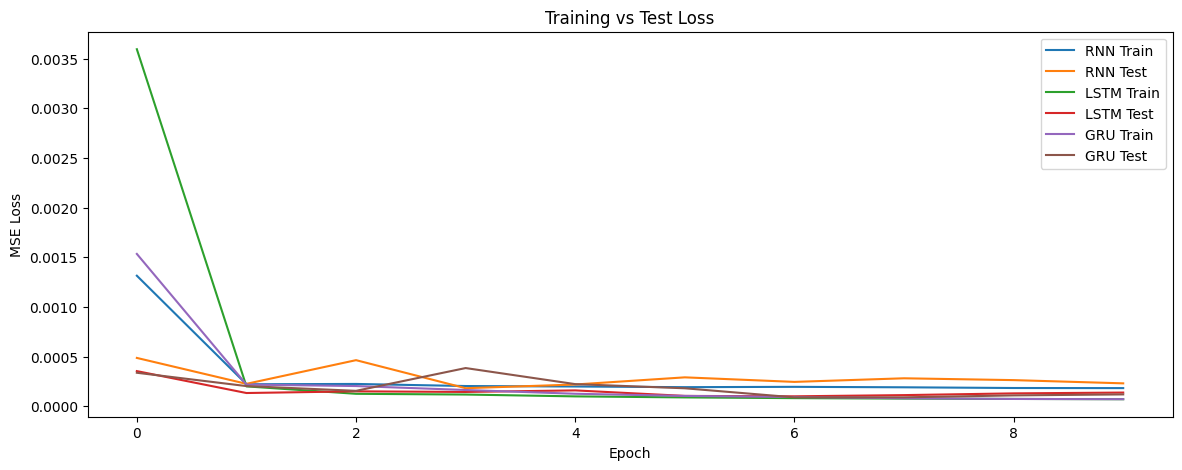

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(rnn_train_losses, label="RNN Train")
plt.plot(rnn_test_losses, label="RNN Test")
plt.plot(lstm_train_losses, label="LSTM Train")
plt.plot(lstm_test_losses, label="LSTM Test")
plt.plot(gru_train_losses, label="GRU Train")
plt.plot(gru_test_losses, label="GRU Test")
plt.title("Training vs Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [ ]:
rnn_preds, rnn_actuals, rnn_mae, rnn_rmse = evaluate_model(rnn_model, test_loader, scaler, "RNN")

RNN MAE: 569.7399
RNN RMSE: 720.4416


In [ ]:
lstm_preds, lstm_actuals, lstm_mae, lstm_rmse = evaluate_model(lstm_model, test_loader, scaler, "LSTM")

LSTM MAE: 419.7867
LSTM RMSE: 556.6111


In [ ]:
gru_preds, gru_actuals, gru_mae, gru_rmse = evaluate_model(gru_model, test_loader, scaler, "GRU")

GRU MAE: 400.8416
GRU RMSE: 517.9578


In [ ]:
results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "MAE": [rnn_mae, lstm_mae, gru_mae],
    "RMSE": [rnn_rmse, lstm_rmse, gru_rmse]
})

results.sort_values("RMSE")

,Model,MAE,RMSE
2,GRU,400.841644,517.957799
1,LSTM,419.786682,556.611119
0,RNN,569.739868,720.441596


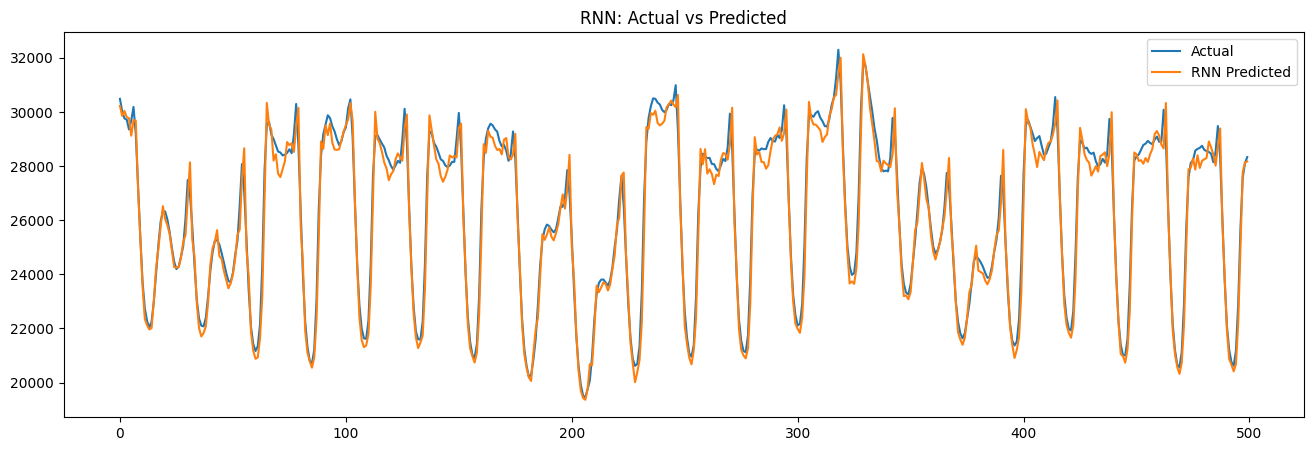

In [ ]:
plt.figure(figsize=(16, 5))
plt.plot(rnn_actuals[:500], label="Actual")
plt.plot(rnn_preds[:500], label="RNN Predicted")
plt.title("RNN: Actual vs Predicted")
plt.legend()
plt.show()

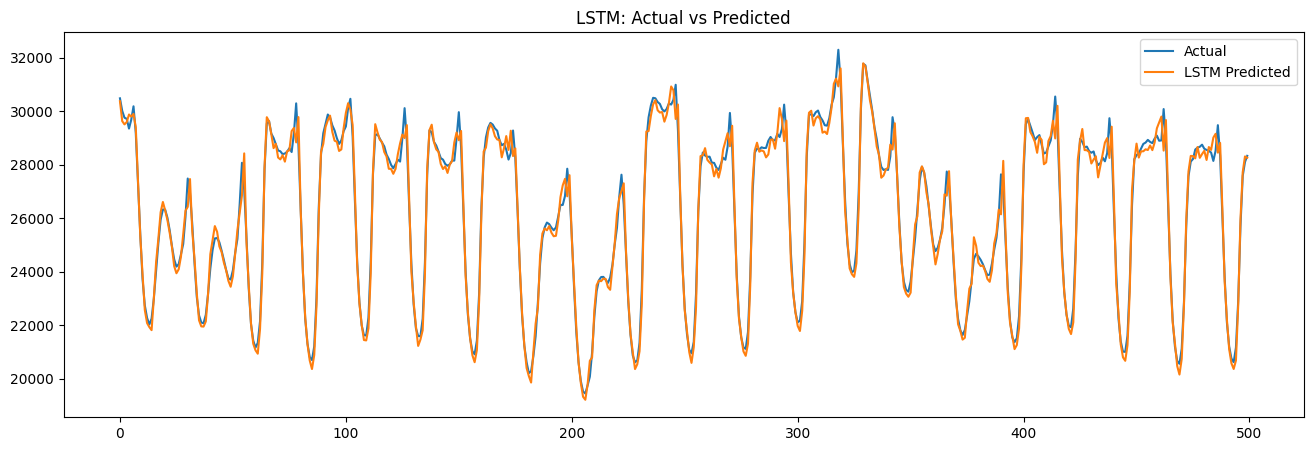

In [ ]:
plt.figure(figsize=(16, 5))
plt.plot(lstm_actuals[:500], label="Actual")
plt.plot(lstm_preds[:500], label="LSTM Predicted")
plt.title("LSTM: Actual vs Predicted")
plt.legend()
plt.show()

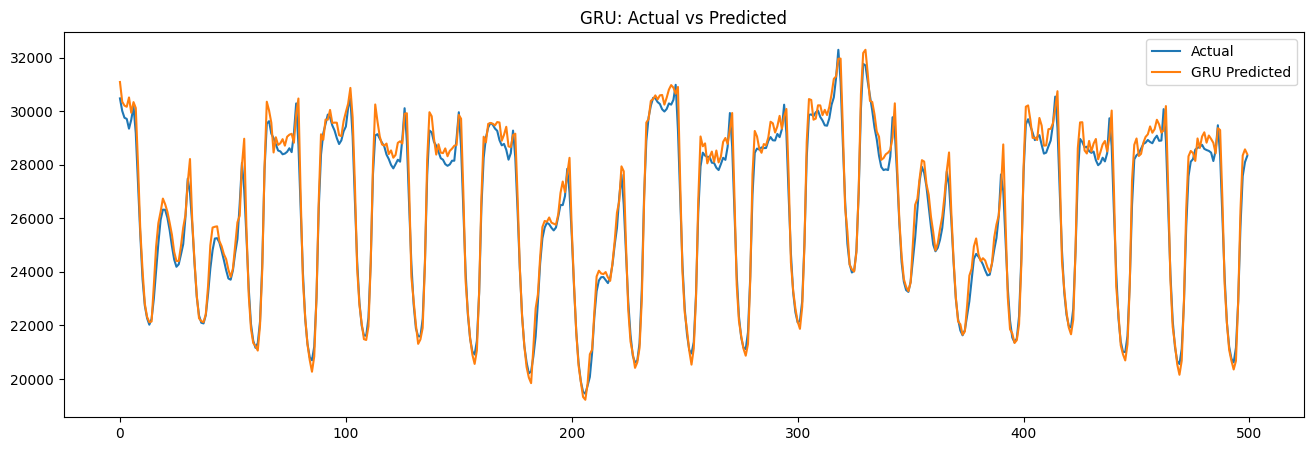

In [ ]:
plt.figure(figsize=(16, 5))
plt.plot(gru_actuals[:500], label="Actual")
plt.plot(gru_preds[:500], label="GRU Predicted")
plt.title("GRU: Actual vs Predicted")
plt.legend()
plt.show()

In [ ]:
torch.save(gru_model.state_dict(), "best_gru_model.pt")

from google.colab import files
files.download("best_gru_model.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>